### Imports and plotting setting

In [1]:
import numpy as np
from scipy.optimize import fsolve, root

# import predefined functions wich solve the box model
import fct_BoxModel as fbm

import xarray as xr
import pandas as pd
import matplotlib
from matplotlib import cm
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
import cv2 as cv

from matplotlib import colors

from cmcrameri import cm as cmcra



matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=128):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

lipari_cut = truncate_colormap(cmcra.lipari, minval=0.15, maxval=1.0, n=128)

### Importing the input dataset

In [2]:
# inputs from BoxToReal.ipynb
inputs = xr.open_dataset("model_input_dataset.nc")
index_isf = inputs.Nisf.values
name_isf = inputs.name_isf.values

### Defining the parameters

In [3]:
#PICO parameters
# Reese 2018
C = 1e6 #m^6/s/kg
gammaT = 2e-5 #m/s

#Vertical mixing
# ~Olbers & Hellmer 2010
kappa_diff = 1e-7  # m/s
kappa_conv = 1e-3 # m/s

#Polynia
g = 20

#AABW
C2 = 4e6 #m^6/s/kg

### Plot Figure 3

Ross
Filchner-Ronne
Amery
Dotson
Pine Island
Riiser-Larsen
Roi Baudouin
no conv, diff 0 1
no conv, diff 1 1
no conv, diff 0 2


/mnt/c/Users/louis/Documents/GitHub/Low-Dimensionnal-Model-2025/fct_BoxModel.py:40: RuntimeWarning: invalid value encountered in sqrt
  x0 = -g1[0]/(2*C*rho_star*(beta*s-alpha))+np.sqrt((g1[0]/(2*C*rho_star*(beta*s-alpha)))**2-g1[0]*T_st_0/(C*rho_star*(beta*s-alpha)))


Totten
Moscow Univ.


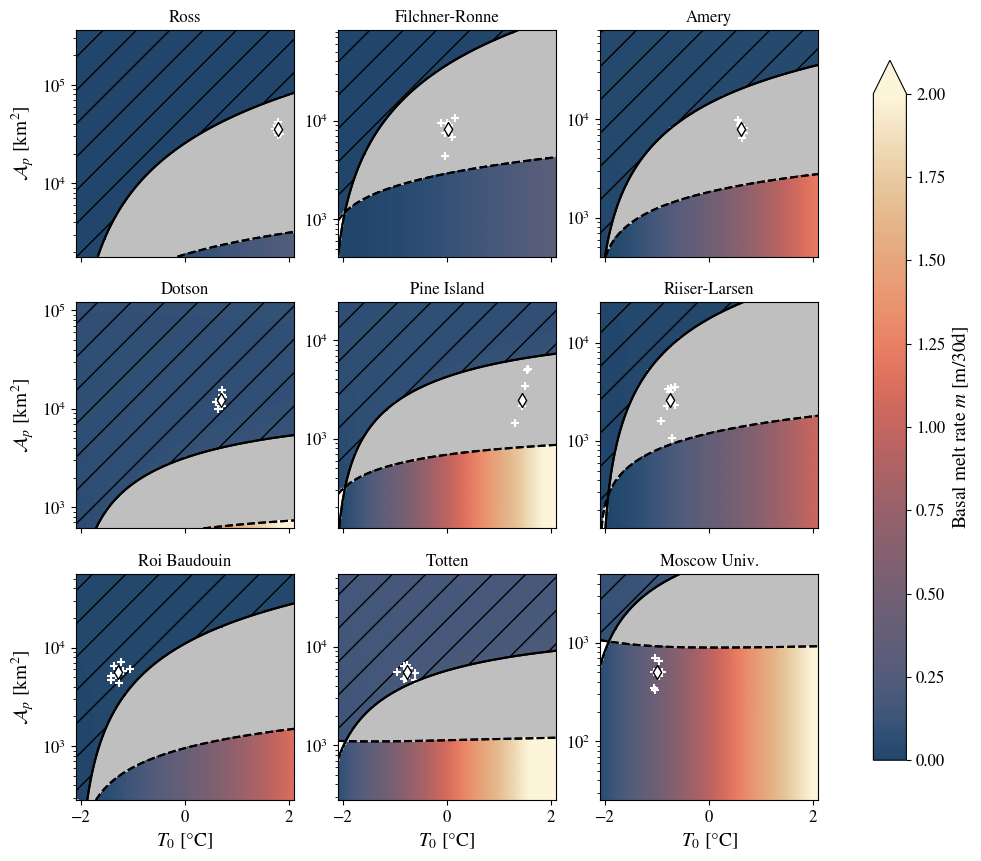

In [5]:
# Warning if computation take to much time, maybe the algotithm can't find some fixed point. Just launch it again because no convergence is tackle with a random walk exploration of the phase space
np.random.seed(0) # this random see works well

AABW = False # If you want to include AABW parameterisation

fig, ax = plt.subplots(3,3,figsize=(11,10),sharex=True)

Npoint = 100 #Number of points in the figures (total is Npoint**2)

#WDW temperature
T0_list = np.linspace(-2.1,2.1,Npoint)

for k, index, name in zip(np.arange(9),index_isf,name_isf):
    print(name)

    #Polynya extents
    Ap_ref = np.mean(inputs.Ap.sel(Nisf=index).values)
    Ap_list = np.logspace(np.log10(Ap_ref/20),np.log10(Ap_ref*10),Npoint)
    
    
    i = k//3
    j = k%3


    stability_d = np.zeros((Npoint,Npoint))
    stability_c = np.zeros((Npoint,Npoint))

    melt_d = np.zeros((Npoint,Npoint))
    melt_c = np.zeros((Npoint,Npoint))

    sigma_d = np.zeros((Npoint,Npoint))
    sigma_c = np.zeros((Npoint,Npoint))
    
    nbox = int(inputs.Nbox.sel(Nisf=index).values)
    Ac = inputs.Ac.sel(Nisf=index).values #m^2

    Omega_ref = np.mean(inputs.Omega.sel(Nisf=index).values)/30/24/3600 #m/s
    
    frac = inputs.frac.sel(Nisf=index).values
    depth = inputs.depth.sel(Nisf=index).values
    T_surf_ref = np.mean(inputs.T_surf.sel(Nisf=index).values)
    S_surf_ref = np.mean(inputs.S_surf.sel(Nisf=index).values)
    S0_ref = np.mean(inputs.S0.sel(Nisf=index).values)

    # initial guess for the steady stae of the system
    guess_conv_0 = np.array([0,0,35.5,35.5])
    guess_diff_0 = np.array([0,0,35.5,35.5])
    
    for n, T0 in enumerate(T0_list):

        guess_conv = guess_conv_0
        guess_diff = guess_diff_0
        
        for m, Ap in enumerate(Ap_list):
                
    
            X_d, info, ier, msg = fsolve(fbm.BoxModel, guess_diff, args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_diff,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True,)
            if ier != 1: #management of non convergence cases
                incr = 0
                while ier != 1 or X_d[3]<30 or X_d[1]<30:
                    X_d, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess_diff,0.15), args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
                    incr += 1
                    if incr == 200:
                        print('no conv, diff',m,n)
                        break
            # update initial guess
            if ier == 1:
                guess_diff = X_d
                if m==0:
                    guess_diff_0 = X_d 

            if ier==1:
                sigma_d[m,n] = fbm.compute_Sigma(X_d)
                stability_d[m,n] = fbm.compute_Sigma(X_d)<0
                if stability_d[m,n]:
                    T,S,melt,q = fbm.PICO(X_d[1],X_d[3], nbox, C, gammaT, Ac, frac, depth)
                    melt_d[m,n] = fbm.compute_m_avg(melt,frac,nbox)
                    #melt_d[m,n] = melt[0] # only in first box
                else:
                    melt_d[m,n] = np.nan
            else:
                stability_d[m,n] = np.nan
                melt_d[m,n] = np.nan
                
            
            X_c, info, ier, msg = fsolve(fbm.BoxModel, guess_conv, args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
            if ier != 1: #management of non convergence cases
                incr = 0
                while ier != 1:
                    X_c, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess_conv,0.15), args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
                    incr += 1
                    if incr == 200:
                        print('no conv, conv',m,n)
                        break
            # update initial guess
            if ier==1:
                guess_conv = X_c
                if m==0:
                    guess_conv_0 = X_c
            

            if ier==1:
                sigma_c[m,n] = fbm.compute_Sigma(X_c)
                stability_c[m,n] = fbm.compute_Sigma(X_c)>0
                if stability_c[m,n]:
                    T,S,melt,q = fbm.PICO(X_c[1],X_c[3], nbox, C, gammaT, Ac, frac, depth)
                    melt_c[m,n] = fbm.compute_m_avg(melt,frac,nbox)
                    #melt_c[m,n] = melt[0]  # only in first box
                else:
                    melt_c[m,n] = np.nan
            else:
                stability_c[m,n] = np.nan
                melt_c[m,n] = np.nan

            
    # show monostable and bistable cases
    stability_map = np.logical_and(stability_c,stability_d)*0 + np.logical_and(stability_c,np.logical_not(stability_d))*(-1) + np.logical_and(np.logical_not(stability_c),stability_d)*1

    # show unstable cases 
    stability_map = np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)), stability_map)

    ax[i,j].pcolormesh(T0_list,Ap_list/1e6,melt_c,cmap=lipari_cut,vmin=0,vmax=2,shading='gouraud') # Ap in km²
    melt_diff = ax[i,j].pcolormesh(T0_list,Ap_list/1e6,melt_d,cmap=lipari_cut,vmin=0,vmax=2,shading='gouraud') # Ap in km²
    bistable_zone = np.ma.masked_where(np.logical_not(np.logical_and(stability_c,stability_d)),np.logical_and(stability_c,stability_d)*0.25)
    ax[i,j].pcolormesh(T0_list,Ap_list/1e6,bistable_zone,cmap='binary',vmin=0,vmax=1) # Ap in km²

    ax[i,j].contour(T0_list,Ap_list/1e6,sigma_d,colors='black',levels=0)
    ax[i,j].contour(T0_list,Ap_list/1e6,sigma_c,colors='black',levels=0,linestyles='dashed')

    if np.max(sigma_d)>0:
        ax[i,j].contour(T0_list,Ap_list/1e6,sigma_d,colors='black',levels=0)
        ax[i,j].contourf(T0_list,Ap_list/1e6,np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)),sigma_d),hatches='/',levels=[0,500],alpha=0)
    if np.min(sigma_c)<0:
        ax[i,j].contour(T0_list,Ap_list/1e6,sigma_c,colors='black',levels=0,linestyles='dashed')
    
    ax[i,j].set_title(name)
    ax[i,j].set_yscale('log')
    ax[i,j].set_xlim((-2.1,2.1))
    ax[i,j].set_ylim((Ap_list.min()/1e6,Ap_list.max()/1e6))
    
    if j==0:
        ax[i,j].set_ylabel(r'$\mathcal{A}_p$'+' '+r'$\mathrm{[km^2]}$')
    if i==2:
        ax[i,j].set_xlabel(r'$T_0$'+' [°C]')

    T0_series = inputs.T0.sel(Nisf=index).values
    Ap_series = inputs.Ap.sel(Nisf=index).groupby('time.year').mean('time').values
    
    ax[i,j].scatter(T0_series,Ap_series/1e6,marker='+', c='white') # Ap in km²

    ax[i,j].scatter(np.mean(T0_series),np.mean(Ap_series)/1e6,facecolors='white',edgecolors='black',marker='d',s=50,linewidths=1) #interannual mean

    
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.03, 0.7])
fig.colorbar(melt_diff,cax=cbar_ax, label = 'Basal melt rate '+r'$m$'+' [m/30d]', extend='max')
plt.savefig('Figures/Figure3.png',dpi=300,format="png", bbox_inches = 'tight')
plt.show()